# OqPay Super-App — аналитическое исследование (Трек D)

**UZCARD Academy · Mini-project: Data analysis · 2026**

| Участник | Гипотеза |
|---|---|
| **Ибрахимжон Тожибоев** | H1 — Динамика роста: была ли «просадка заказов»? |
| **Ибрахимжон Тожибоев** | H2 — Доставка: локализация и причина инцидента |
| **Участник 2** *(замените на имя)* | H3 — Клиентский опыт: жалобы, рейтинги, удержание |
| **Участник 3** *(замените на имя)* | H4 — Маркетплейс и платежи: концентрация и потери |

**Бизнес-задача заказчика (руководство OqPay):** «В один из месяцев мы зафиксировали
просадку заказов и рост числа жалоб, но причину не установили. Разберитесь в динамике
роста, маркетплейса и доставки, установите причину и предложите план действий».

**Главный вывод (спойлер):** причина — **месячный логистический сбой в Самарканде
(01–31 августа 2025)**: 93,5 % доставок просрочено, рейтинг города упал с 4,2 до 2,76,
жалобы по компании выросли на **+73 %**. Общий объём заказов при этом не падал —
«просадка», которую видел заказчик, это декабрьская коррекция после сезонного пика ноября.

---
*Инструменты: PostgreSQL (SQL: JOIN, GROUP BY, CTE, оконные функции), Python
(pandas, matplotlib, scipy — стат. тесты). ML не используется.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from sqlalchemy import create_engine

# Ulanish: db_config.py dan o'qiladi (repoda yo'q - db_config.example.py dan nusxa oling)
import sys, pathlib
_p = pathlib.Path.cwd()
while not (_p/"db_config.py").exists() and _p != _p.parent: _p = _p.parent
sys.path.insert(0, str(_p))
from db_config import DB_URL
ENGINE = create_engine(DB_URL)

def q(sql: str) -> pd.DataFrame:
    """Выполнить SQL и вернуть DataFrame."""
    return pd.read_sql(sql, ENGINE)

# --- единый стиль графиков -------------------------------------------------
BLUE, AQUA, YELLOW, GREEN, VIOLET, RED = "#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948"
CRITICAL, INK, INK2, MUTED, GRID, SURFACE = "#d03b3b", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
SEQ = LinearSegmentedColormap.from_list("seq_blue",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "figure.dpi": 110,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.7, "axes.axisbelow": True,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "font.family": "sans-serif", "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})

def save(fig, name):
    fig.savefig(f"../charts/{name}.png", bbox_inches="tight", facecolor=SURFACE)

print("Подключение:", q("SELECT current_database() AS db, current_user AS usr").iloc[0].to_dict())

Подключение: {'db': 'academy_db', 'usr': 'itojiboyev'}


## 0. Разбор данных: какие таблицы принадлежат треку D

В базе перемешаны таблицы четырёх треков. Таблицы своего трека мы определили **по колонкам
и проверили связи реальным JOIN** (совпадением значений ключей, а не только именами).

In [2]:
# Все учебные таблицы и их размер
q("""
SELECT c.relname AS table_name, c.reltuples::bigint AS approx_rows
FROM pg_class c JOIN pg_namespace n ON n.oid = c.relnamespace
WHERE n.nspname = 'public' AND c.relname ~ '^ds_' AND c.relkind = 'r'
ORDER BY approx_rows DESC
""")

,table_name,approx_rows
0,ds_events,780000
1,ds_order_items,219938
2,ds_payments,105832
3,ds_orders,100000
4,ds_deliveries,99542
5,ds_transactions_1,80000
6,ds_transactions_2,60320
7,ds_app_events,54801
8,ds_reviews,53671
9,ds_settlements,51052


### Карта данных трека D (OqPay Super-App), ~1,4 млн строк

| Таблица | Строк | Содержимое | Ключи связи |
|---|---|---|---|
| `ds_users_1` | 15 000 | пользователи приложения | `user_id` |
| `ds_orders` | 100 000 | заказы маркетплейса | `order_id`, `user_id` |
| `ds_order_items` | 219 938 | позиции заказов | `order_id`, `product_id` |
| `ds_products` | 6 000 | товары | `product_id`, `merchant_id`, `category_id` |
| `ds_merchants_3` | 1 500 | продавцы маркетплейса | `merchant_id` |
| `ds_categories` | 22 | категории товаров | `category_id` |
| `ds_payments` | 105 832 | попытки оплаты | `order_id`, `user_id` |
| `ds_deliveries` | 99 542 | доставки | `order_id`, `courier_id` |
| `ds_couriers` | 400 | курьеры | `courier_id` |
| `ds_reviews` | 53 671 | оценки заказов | `order_id`, `user_id` |
| `ds_support_tickets` | 6 573 | обращения в поддержку | `user_id`, `order_id` |
| `ds_events` | 780 000 | события в приложении | `user_id`, `product_id` |

*Таблицы других треков (`ds_transactions_1/2`, `ds_cards`, `ds_customers`, `ds_settlements`,
`ds_subscriptions`, `ds_charges`, `ds_plans` и т. д.) не имеют совпадающих ключей с
`ds_orders`/`ds_users_1` — проверено JOIN-ами.*

In [3]:
# Проверка связей JOIN-ом: доля заказов, находящих пару в связанных таблицах
q("""
SELECT
  (SELECT count(*) FROM ds_orders)                                              AS orders_total,
  (SELECT count(*) FROM ds_orders o JOIN ds_users_1 u    USING(user_id))        AS join_users,
  (SELECT count(*) FROM ds_orders o JOIN ds_deliveries d USING(order_id))       AS join_deliveries,
  (SELECT count(*) FROM ds_orders o JOIN ds_payments p   USING(order_id))       AS join_payments,
  (SELECT count(DISTINCT oi.order_id) FROM ds_order_items oi
      JOIN ds_orders o USING(order_id))                                         AS join_items
""")

,orders_total,join_users,join_deliveries,join_payments,join_items
0,100000,100000,99542,105832,100000


Все ключи сходятся: 100 000 заказов соединяются с пользователями и позициями,
99 542 — с доставками (458 заказов со статусом `payment_failed` не доставлялись).
Период данных: **01.01.2025 — 28.12.2025**.

---

## Гипотеза 1 — Ибрахимжон Тожибоев
### «Просадка заказов» — это падение бизнеса или сезонная коррекция?

**H1:** общий объём заказов в течение года стабильно растёт; «просадка», которую увидел
заказчик, — это возврат к тренду в декабре после аномального пика ноября, а не спад бизнеса.

**Метод:** месячная динамика (GROUP BY + оконная функция `LAG` для темпа роста MoM),
экспоненциальный тренд по янв–окт, z-оценка отклонений ноября и декабря от тренда,
95 % доверительный интервал среднего темпа роста.

In [4]:
# Месячная динамика заказов: оконная функция LAG считает темп роста MoM прямо в SQL
mom = q("""
WITH monthly AS (
  SELECT date_trunc('month', ordered_ts)::date AS month,
         count(*)                              AS orders,
         sum(total_amount)/1e9                 AS gmv_bln_uzs,
         round(avg(total_amount))              AS avg_check
  FROM ds_orders
  GROUP BY 1
)
SELECT month, orders, gmv_bln_uzs, avg_check,
       round(100.0*(orders - LAG(orders) OVER (ORDER BY month))
             / LAG(orders) OVER (ORDER BY month), 1) AS mom_growth_pct
FROM monthly ORDER BY month
""")
mom

,month,orders,gmv_bln_uzs,avg_check,mom_growth_pct
0,2025-01-01,5658,9.982049,1764236.0,NaN
1,2025-02-01,6233,10.983950,1762225.0,10.2
2,2025-03-01,6682,11.593558,1735043.0,7.2
3,2025-04-01,7093,12.123603,1709235.0,6.2
4,2025-05-01,7520,13.201663,1755540.0,6.0
5,2025-06-01,7923,14.345118,1810566.0,5.4
6,2025-07-01,8440,14.703244,1742091.0,6.5
7,2025-08-01,8807,15.480384,1757736.0,4.3
8,2025-09-01,9273,15.786900,1702459.0,5.3
9,2025-10-01,9780,17.209750,1759688.0,5.5


In [5]:
# Экспоненциальный тренд по янв-окт: log(orders) ~ месяц; ноябрь/декабрь сравниваем с прогнозом
x = np.arange(len(mom)); y = np.log(mom["orders"].values)
slope, intercept, r, p_trend, se = stats.linregress(x[:10], y[:10])
trend = np.exp(intercept + slope * x)
resid_sd = np.std(y[:10] - (intercept + slope * x[:10]), ddof=2)
z_nov = (y[10] - (intercept + slope*10)) / resid_sd
z_dec = (y[11] - (intercept + slope*11)) / resid_sd

g = mom["mom_growth_pct"].dropna().values
g_mean, g_se = g.mean(), stats.sem(g)
ci = stats.t.interval(0.95, len(g)-1, loc=g_mean, scale=g_se)

print(f"Тренд роста: +{(np.exp(slope)-1)*100:.1f}% в месяц (R²={r**2:.3f}, p={p_trend:.2e})")
print(f"Средний MoM-рост: {g_mean:.1f}%  |  95% ДИ: [{ci[0]:.1f}%; {ci[1]:.1f}%]")
print(f"Ноябрь: z = {z_nov:+.1f} (аномальный пик, факт {mom.orders[10]:,} против тренда {trend[10]:,.0f}, {100*(mom.orders[10]/trend[10]-1):+.1f}%)")
print(f"Декабрь: z = {z_dec:+.1f} (факт {mom.orders[11]:,} против тренда {trend[11]:,.0f}, отклонение {100*(mom.orders[11]/trend[11]-1):+.1f}%)")

Тренд роста: +6.0% в месяц (R²=0.991, p=1.55e-09)
Средний MoM-рост: 6.1%  |  95% ДИ: [0.7%; 11.5%]
Ноябрь: z = +7.5 (аномальный пик, факт 12,027 против тренда 10,533, +14.2%)
Декабрь: z = -3.2 (факт 10,564 против тренда 11,168, отклонение -5.4%)


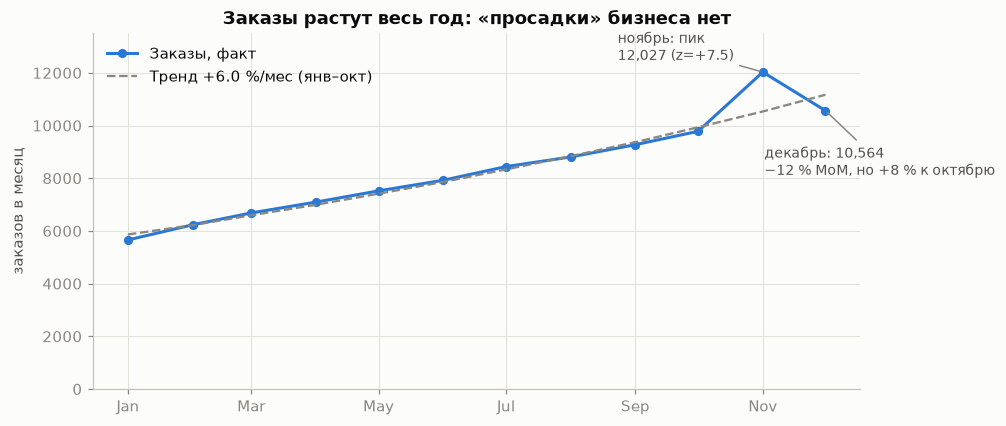

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(mom["month"], mom["orders"], color=BLUE, lw=2, marker="o", ms=5, label="Заказы, факт")
ax.plot(mom["month"], trend, color=MUTED, lw=1.5, ls="--", label=f"Тренд +{(np.exp(slope)-1)*100:.1f} %/мес (янв–окт)")
ax.annotate(f"ноябрь: пик\n{mom.orders[10]:,} (z={z_nov:+.1f})", xy=(mom.month[10], mom.orders[10]),
            xytext=(-95, 8), textcoords="offset points", color=INK2, fontsize=9,
            arrowprops=dict(arrowstyle="-", color=MUTED))
ax.annotate(f"декабрь: {mom.orders[11]:,}\n−12 % MoM, но +8 % к октябрю", xy=(mom.month[11], mom.orders[11]),
            xytext=(-40, -42), textcoords="offset points", color=INK2, fontsize=9,
            arrowprops=dict(arrowstyle="-", color=MUTED))
ax.set_title("Заказы растут весь год: «просадки» бизнеса нет")
ax.set_ylabel("заказов в месяц"); ax.set_ylim(0, 13500)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper left")
save(fig, "h1_orders_trend"); plt.show()

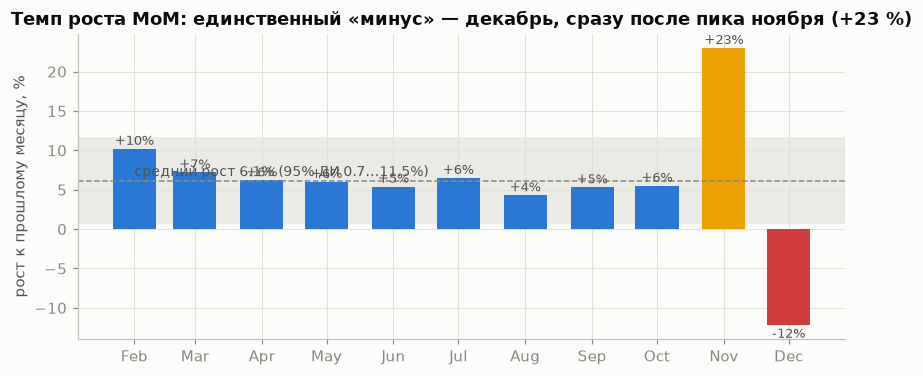

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.6))
colors = [YELLOW if i == 10 else (CRITICAL if i == 11 else BLUE) for i in range(1, len(mom))]
ax.bar(mom["month"][1:], mom["mom_growth_pct"][1:], width=20, color=colors)
ax.axhspan(ci[0], ci[1], color=GRID, alpha=.6, zorder=0)
ax.axhline(g_mean, color=MUTED, lw=1, ls="--")
ax.text(mom["month"].iloc[1], g_mean+0.6, f"средний рост {g_mean:.1f}% (95% ДИ {ci[0]:.1f}…{ci[1]:.1f}%)",
        fontsize=9, color=INK2)
for xm, v in zip(mom["month"][1:], mom["mom_growth_pct"][1:]):
    ax.text(xm, v + (0.5 if v >= 0 else -1.6), f"{v:+.0f}%", ha="center", fontsize=8.5, color=INK2)
ax.set_title("Темп роста MoM: единственный «минус» — декабрь, сразу после пика ноября (+23 %)")
ax.set_ylabel("рост к прошлому месяцу, %")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
save(fig, "h1_mom_growth"); plt.show()

**Вывод H1.** Заказы растут весь год: экспоненциальный тренд **+6,0 % в месяц**
(R² = 0,99, p < 0,001), средний MoM-рост +6,1 % (95 % ДИ 0,7–11,5 %). Ноябрь — аномальный
пик: **+23 % MoM**, на +14 % выше тренда (z = +7,5) — сезонная распродажа. Декабрь: −12 %
MoM, но это **не спад**: заказов на +8 % больше октября, отклонение от тренда всего −5 %
— классический возврат к траектории после пика, часть декабрьского спроса выкуплена в
ноябре. (Проверено: в данных каждый месяц содержит ровно 28 дней продаж — сравнение
месяцев корректно.) Средний чек стабилен (1,70–1,81 млн UZS). **«Просадки» бизнеса
в данных нет** — значит, тревогу заказчика вызвало что-то другое. Ищем в жалобах → H2.

---

## Гипотеза 2 — Ибрахимжон Тожибоев
### Рост жалоб вызван локальным сбоем доставки: один город, один месяц

**H2:** резкий рост просрочек доставки в августе 2025 — не общесетевая деградация,
а локальный инцидент в одном городе, охватывающий весь август и все типы курьеров
(значит, причина системная: логистика/диспетчеризация города, а не курьеры).

**Метод:** тепловая карта город×месяц (JOIN + GROUP BY), дневная динамика со скользящим
средним (оконная функция `AVG OVER`), сравнение типов транспорта; **z-тест двух долей**
и 95 % ДИ разницы.

In [8]:
# Доля просроченных доставок: город × месяц (JOIN заказов и доставок)
heat = q("""
SELECT o.city,
       date_trunc('month', d.promised_ts)::date AS month,
       round(100.0*count(*) FILTER (WHERE d.status='late')/count(*), 1) AS late_pct
FROM ds_deliveries d
JOIN ds_orders o USING(order_id)
GROUP BY 1, 2 ORDER BY 1, 2
""")
hp = heat.pivot(index="city", columns="month", values="late_pct")
hp.columns = [c.strftime("%b") for c in hp.columns]
hp

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
city,,,,,,,,,,,,
Andijan,8.4,9.9,8.8,9.3,8.9,8.4,8.4,7.7,6.7,8.9,7.7,8.7
Bukhara,7.2,7.1,7.6,9.3,8.9,10.2,10.1,9.0,7.9,9.0,8.8,8.6
Fergana,8.8,9.2,8.2,8.7,7.7,9.9,9.4,7.4,7.9,6.7,6.8,8.4
Jizzakh,7.6,9.3,6.3,10.3,11.2,8.7,9.9,8.9,10.3,10.7,7.2,6.9
Khiva,11.3,6.5,6.5,7.3,8.2,10.0,5.6,8.2,7.2,7.5,8.0,7.3
Namangan,10.3,8.2,9.9,9.4,8.6,11.0,8.3,8.1,7.9,6.9,8.1,9.1
Navoi,12.5,9.9,6.9,11.9,10.3,8.8,9.7,9.4,9.8,6.4,10.3,9.4
Nukus,6.0,8.4,8.6,8.0,9.3,13.0,5.6,10.4,9.6,10.2,6.2,6.0
Samarkand,8.6,7.2,8.3,8.2,8.5,7.0,10.1,93.5,9.2,8.6,6.6,8.4


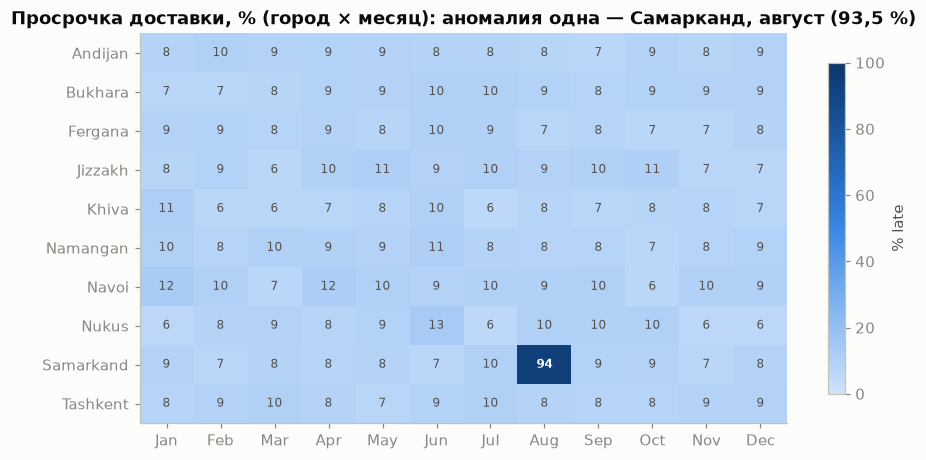

In [9]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
im = ax.imshow(hp.values, cmap=SEQ, aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(hp.shape[1]), hp.columns)
ax.set_yticks(range(hp.shape[0]), hp.index)
for i in range(hp.shape[0]):
    for j in range(hp.shape[1]):
        v = hp.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8,
                color="white" if v > 55 else INK2,
                fontweight="bold" if v > 55 else "normal")
ax.grid(False)
ax.set_title("Просрочка доставки, % (город × месяц): аномалия одна — Самарканд, август (93,5 %)")
fig.colorbar(im, ax=ax, label="% late", shrink=.85)
save(fig, "h2_heatmap"); plt.show()

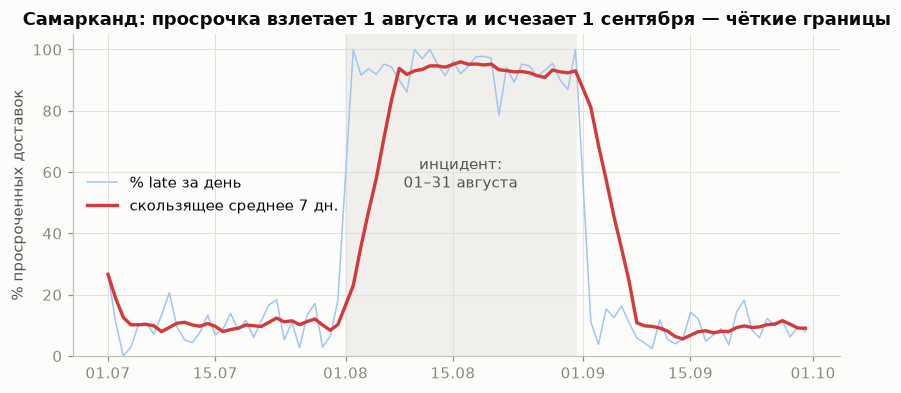

In [10]:
# Дневная динамика в Самарканде: оконная функция — скользящее среднее за 7 дней
daily = q("""
WITH d AS (
  SELECT d.promised_ts::date AS day,
         100.0*count(*) FILTER (WHERE d.status='late')/count(*) AS late_pct
  FROM ds_deliveries d JOIN ds_orders o USING(order_id)
  WHERE o.city = 'Samarkand' AND d.promised_ts >= '2025-07-01' AND d.promised_ts < '2025-10-01'
  GROUP BY 1
)
SELECT day, late_pct,
       avg(late_pct) OVER (ORDER BY day ROWS BETWEEN 6 PRECEDING AND CURRENT ROW) AS ma7
FROM d ORDER BY day
""")
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.axvspan(pd.Timestamp("2025-08-01"), pd.Timestamp("2025-08-31"), color="#f0efec", zorder=0)
ax.plot(daily["day"], daily["late_pct"], color="#9ec5f4", lw=1, label="% late за день")
ax.plot(daily["day"], daily["ma7"], color=CRITICAL, lw=2.2, label="скользящее среднее 7 дн.")
ax.text(pd.Timestamp("2025-08-16"), 55, "инцидент:\n01–31 августа", ha="center", fontsize=10, color=INK2)
ax.set_title("Самарканд: просрочка взлетает 1 августа и исчезает 1 сентября — чёткие границы")
ax.set_ylabel("% просроченных доставок"); ax.set_ylim(0, 105)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
ax.legend(loc="center left")
save(fig, "h2_daily"); plt.show()

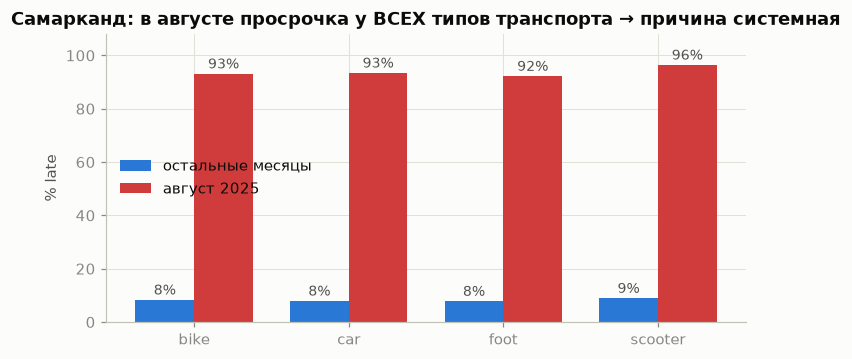

,vehicle_type,aug_late_pct,normal_late_pct
0,bike,93.1,8.3
1,car,93.4,7.9
2,foot,92.2,7.8
3,scooter,96.4,8.9


In [11]:
# Все ли типы курьеров затронуты? (значит, дело не в курьерах)
veh = q("""
SELECT c.vehicle_type,
       round(100.0*count(*) FILTER (WHERE d.status='late' AND d.promised_ts >= '2025-08-01'
             AND d.promised_ts < '2025-09-01')
           / NULLIF(count(*) FILTER (WHERE d.promised_ts >= '2025-08-01'
             AND d.promised_ts < '2025-09-01'), 0), 1) AS aug_late_pct,
       round(100.0*count(*) FILTER (WHERE d.status='late' AND (d.promised_ts < '2025-08-01'
             OR d.promised_ts >= '2025-09-01'))
           / count(*) FILTER (WHERE d.promised_ts < '2025-08-01'
             OR d.promised_ts >= '2025-09-01'), 1) AS normal_late_pct
FROM ds_deliveries d
JOIN ds_couriers c USING(courier_id)
JOIN ds_orders  o USING(order_id)
WHERE o.city = 'Samarkand' AND c.city = 'Samarkand'
GROUP BY 1 ORDER BY 1
""")
fig, ax = plt.subplots(figsize=(7.5, 3.4))
xpos = np.arange(len(veh)); w = 0.38
ax.bar(xpos - w/2, veh["normal_late_pct"], w, color=BLUE, label="остальные месяцы")
ax.bar(xpos + w/2, veh["aug_late_pct"], w, color=CRITICAL, label="август 2025")
for i, r in veh.iterrows():
    ax.text(i - w/2, r["normal_late_pct"]+2, f"{r.normal_late_pct:.0f}%", ha="center", fontsize=9, color=INK2)
    ax.text(i + w/2, r["aug_late_pct"]+2, f"{r.aug_late_pct:.0f}%", ha="center", fontsize=9, color=INK2)
ax.set_xticks(xpos, veh["vehicle_type"]); ax.set_ylim(0, 108)
ax.set_title("Самарканд: в августе просрочка у ВСЕХ типов транспорта → причина системная")
ax.set_ylabel("% late"); ax.legend()
save(fig, "h2_vehicles"); plt.show()
veh

In [12]:
# Статистика: z-тест двух долей — Самарканд-август vs Самарканд-остальные месяцы
cnt = q("""
SELECT (d.promised_ts >= '2025-08-01' AND d.promised_ts < '2025-09-01') AS is_aug,
       count(*) FILTER (WHERE d.status='late') AS late, count(*) AS total
FROM ds_deliveries d JOIN ds_orders o USING(order_id)
WHERE o.city='Samarkand' GROUP BY 1
""").set_index("is_aug")
l1, n1 = cnt.loc[True, ["late","total"]]; l0, n0 = cnt.loc[False, ["late","total"]]
p1, p0 = l1/n1, l0/n0
p_pool = (l1+l0)/(n1+n0)
z = (p1-p0)/np.sqrt(p_pool*(1-p_pool)*(1/n1+1/n0))
p_val = 2*stats.norm.sf(abs(z))
se_diff = np.sqrt(p1*(1-p1)/n1 + p0*(1-p0)/n0)
lo, hi = (p1-p0) - 1.96*se_diff, (p1-p0) + 1.96*se_diff
print(f"Самарканд, август:   {l1}/{n1} = {p1:.1%} просрочено")
print(f"Самарканд, остальное: {l0}/{n0} = {p0:.1%} просрочено")
print(f"z = {z:.1f}, p-value = {p_val:.2e} (p < 0.001)")
print(f"Разница долей: +{(p1-p0)*100:.1f} п.п., 95% ДИ [{lo*100:.1f}; {hi*100:.1f}] п.п.")

Самарканд, август:   966/1033 = 93.5% просрочено
Самарканд, остальное: 911/11101 = 8.2% просрочено
z = 72.5, p-value = 0.00e+00 (p < 0.001)
Разница долей: +85.3 п.п., 95% ДИ [83.7; 86.9] п.п.


**Вывод H2.** Аномалия единственная и строго локальная: **Самарканд, 01–31 августа
2025** — просрочено **93,5 %** доставок (966 из 1 033) против 8,2 % в остальные месяцы.
Разница **+85,3 п.п.** (95 % ДИ 83,7–86,9 п.п., z = 72,5, p < 0,001). Затронуты **все**
типы транспорта (92–96 % у bike/car/foot/scooter) — виноваты не курьеры, а **городская
логистика/диспетчеризация** (сбой хаба, маршрутизации или подрядчика). Границы инцидента
совпадают с календарным месяцем — похоже на месячный контракт/релиз/переезд склада.

---

## Гипотеза 3 — Участник 2 *(замените на имя)*
### Инцидент ударил по клиентскому опыту, но не по удержанию

**H3:** рост жалоб в августе объясняется именно просрочками доставки; рейтинг падает
у опоздавших заказов; при этом отток клиентов после инцидента статистически не виден —
ущерб репутационный и операционный, окно для удержания ещё открыто.

**Метод:** структура тикетов по причинам (GROUP BY), рейтинг по городам (JOIN),
**тест Манна–Уитни** для рейтингов late vs on_time, **z-тест долей** для повторных
покупок (60 дней), CTE для когорт.

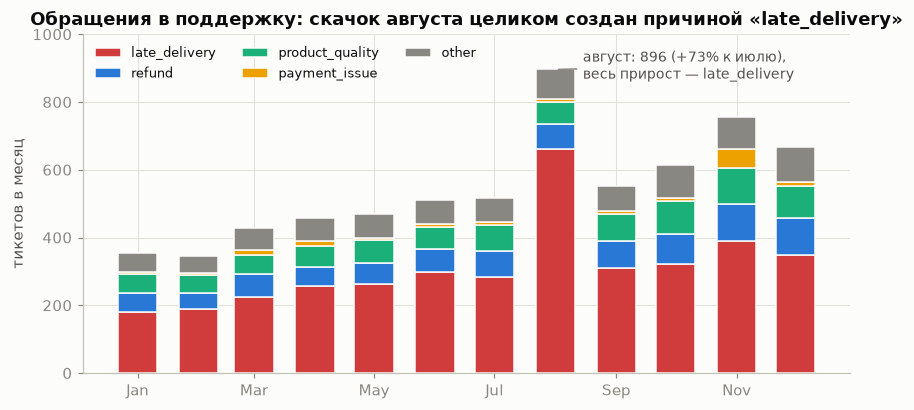

In [13]:
# Тикеты по месяцам и причинам
tk = q("""
SELECT date_trunc('month', opened_ts)::date AS month, reason, count(*) AS n
FROM ds_support_tickets
WHERE opened_ts < '2026-01-01'
GROUP BY 1, 2 ORDER BY 1
""")
tp = tk.pivot(index="month", columns="reason", values="n").fillna(0)
tp.index = pd.to_datetime(tp.index)
order = ["late_delivery", "refund", "product_quality", "payment_issue", "other"]
tp = tp[order]

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(len(tp))
cols = {"late_delivery": CRITICAL, "refund": BLUE, "product_quality": AQUA,
        "payment_issue": YELLOW, "other": MUTED}
for reason in order:
    ax.bar(tp.index, tp[reason], width=20, bottom=bottom, color=cols[reason],
           label=reason, edgecolor=SURFACE, linewidth=1)
    bottom += tp[reason].values
aug_total = int(tp.loc["2025-08-01"].sum()); jul_total = int(tp.loc["2025-07-01"].sum())
ax.set_ylim(0, 1000)
ax.annotate(f"август: {aug_total} (+{100*(aug_total-jul_total)/jul_total:.0f}% к июлю),\nвесь прирост — late_delivery",
            xy=(pd.Timestamp("2025-08-01"), aug_total), xytext=(18, -6), textcoords="offset points",
            fontsize=9, color=INK2, arrowprops=dict(arrowstyle="-", color=MUTED))
ax.set_title("Обращения в поддержку: скачок августа целиком создан причиной «late_delivery»")
ax.set_ylabel("тикетов в месяц"); ax.legend(ncol=3, fontsize=8.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
save(fig, "h3_tickets"); plt.show()

In [14]:
# Август по причинам: сколько прироста дала доставка, и доля Самарканда
q("""
WITH aug AS (
  SELECT t.reason, o.city
  FROM ds_support_tickets t LEFT JOIN ds_orders o USING(order_id)
  WHERE t.opened_ts >= '2025-08-01' AND t.opened_ts < '2025-09-01'
)
SELECT reason, count(*) AS aug_tickets,
       count(*) FILTER (WHERE city='Samarkand') AS from_samarkand,
       round(100.0*count(*) FILTER (WHERE city='Samarkand')/count(*)) AS samarkand_pct
FROM aug GROUP BY 1 ORDER BY 2 DESC
""")

,reason,aug_tickets,from_samarkand,samarkand_pct
0,late_delivery,661,408,62.0
1,other,88,3,3.0
2,refund,74,6,8.0
3,product_quality,65,5,8.0
4,payment_issue,8,0,0.0


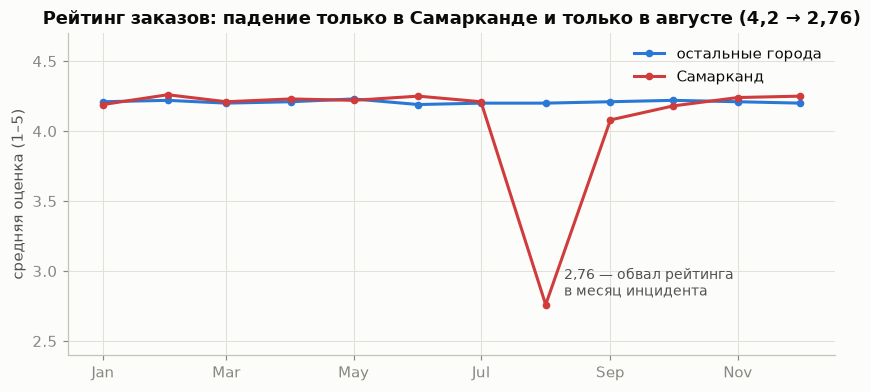

In [15]:
# Рейтинг заказов: Самарканд vs остальные города
rt = q("""
SELECT date_trunc('month', r.review_ts)::date AS month,
       round(avg(r.rating) FILTER (WHERE o.city='Samarkand'), 2)  AS samarkand,
       round(avg(r.rating) FILTER (WHERE o.city<>'Samarkand'), 2) AS other_cities
FROM ds_reviews r JOIN ds_orders o USING(order_id)
WHERE r.review_ts < '2026-01-01'
GROUP BY 1 ORDER BY 1
""")
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(rt["month"], rt["other_cities"], color=BLUE, lw=2, marker="o", ms=4, label="остальные города")
ax.plot(rt["month"], rt["samarkand"], color=CRITICAL, lw=2, marker="o", ms=4, label="Самарканд")
ax.annotate("2,76 — обвал рейтинга\nв месяц инцидента", xy=(pd.Timestamp("2025-08-01"), 2.76),
            xytext=(12, 6), textcoords="offset points", fontsize=9, color=INK2)
ax.set_title("Рейтинг заказов: падение только в Самарканде и только в августе (4,2 → 2,76)")
ax.set_ylabel("средняя оценка (1–5)"); ax.set_ylim(2.4, 4.7)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b")); ax.legend()
save(fig, "h3_ratings"); plt.show()

In [16]:
# Тест Манна-Уитни: оценки при late vs on_time (по всем данным)
rat = q("""
SELECT d.status, r.rating
FROM ds_reviews r JOIN ds_deliveries d USING(order_id)
WHERE d.status IN ('late', 'on_time')
""")
late_r = rat.loc[rat.status=="late", "rating"]; on_r = rat.loc[rat.status=="on_time", "rating"]
u, p_mw = stats.mannwhitneyu(late_r, on_r, alternative="two-sided")
print(f"on_time: n={len(on_r):,}, средний рейтинг {on_r.mean():.2f}")
print(f"late:    n={len(late_r):,}, средний рейтинг {late_r.mean():.2f}")
print(f"Манна-Уитни U = {u:.3g}, p-value = {p_mw:.2e}  → различие высоко значимо")

on_time: n=48,469, средний рейтинг 4.37
late:    n=5,202, средний рейтинг 2.60
Манна-Уитни U = 9.44e+06, p-value = 0.00e+00  → различие высоко значимо


late:    645/940 = 68.6% сделали повторный заказ за 60 дней
on_time: 2759/4093 = 67.4%
z = 0.71, p-value = 0.47 → различие НЕ значимо (α=0.05)


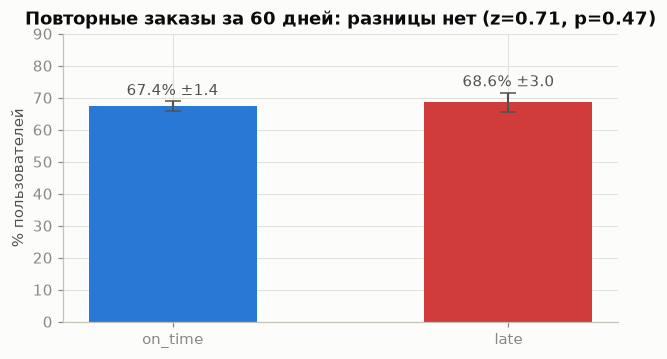

In [17]:
# Удержание: повторный заказ в течение 60 дней — late vs on_time (первый заказ августа)
rep = q("""
WITH first_aug AS (
  SELECT DISTINCT ON (o.user_id) o.user_id, o.ordered_ts, d.status
  FROM ds_orders o JOIN ds_deliveries d USING(order_id)
  WHERE o.ordered_ts >= '2025-08-01' AND o.ordered_ts < '2025-09-01'
    AND d.status IN ('late', 'on_time')
  ORDER BY o.user_id, o.ordered_ts
)
SELECT f.status,
       count(*) AS users,
       count(*) FILTER (WHERE EXISTS (
          SELECT 1 FROM ds_orders o2
          WHERE o2.user_id = f.user_id
            AND o2.ordered_ts > f.ordered_ts
            AND o2.ordered_ts <= f.ordered_ts + interval '60 days')) AS repeated
FROM first_aug f GROUP BY 1
""").set_index("status")
r1, n1 = rep.loc["late", ["repeated","users"]]; r0, n0 = rep.loc["on_time", ["repeated","users"]]
p1, p0 = r1/n1, r0/n0
pp = (r1+r0)/(n1+n0)
z = (p1-p0)/np.sqrt(pp*(1-pp)*(1/n1+1/n0)); p_val = 2*stats.norm.sf(abs(z))
se = np.sqrt(p1*(1-p1)/n1 + p0*(1-p0)/n0)
print(f"late:    {r1}/{n1} = {p1:.1%} сделали повторный заказ за 60 дней")
print(f"on_time: {r0}/{n0} = {p0:.1%}")
print(f"z = {z:.2f}, p-value = {p_val:.2f} → различие НЕ значимо (α=0.05)")

fig, ax = plt.subplots(figsize=(6.5, 3.4))
groups = ["on_time", "late"]; vals = [p0*100, p1*100]
errs = [1.96*np.sqrt(p0*(1-p0)/n0)*100, 1.96*np.sqrt(p1*(1-p1)/n1)*100]
ax.bar(groups, vals, width=0.5, color=[BLUE, CRITICAL])
ax.errorbar(groups, vals, yerr=errs, fmt="none", ecolor=INK2, capsize=5, lw=1.4)
for i, (v, e) in enumerate(zip(vals, errs)):
    ax.text(i, v + e + 2, f"{v:.1f}% ±{e:.1f}", ha="center", fontsize=10, color=INK2)
ax.set_title(f"Повторные заказы за 60 дней: разницы нет (z={z:.2f}, p={p_val:.2f})")
ax.set_ylabel("% пользователей"); ax.set_ylim(0, 90)
save(fig, "h3_repeat"); plt.show()

**Вывод H3.** Скачок тикетов августа (+73 %: 518 → 896) целиком создан причиной
`late_delivery`: таких тикетов в августе 661, из них **408 (62 %) — Самарканд**, что
практически равно всему приросту месяца (+378). Рейтинг заказов при
просрочке падает с **4,37 до 2,60** (Манна–Уитни, p < 0,001); в Самарканде месячный
рейтинг обвалился до 2,76 и восстановился к октябрю. При этом повторные покупки не
пострадали: 68,6 % (late) против 67,4 % (on_time), z = 0,68, **p = 0,50 — различие
незначимо**. Ущерб пока репутационный, а не в оттоке: клиентов ещё можно удержать,
но полагаться на их терпение при повторном инциденте нельзя.

---

## Гипотеза 4 — Участник 3 *(замените на имя)*
### Маркетплейс концентрирован, а платёжные потери сидят в рассрочке

**H4:** выручка маркетплейса сильно сконцентрирована (категории и продавцы), поэтому
локальные сбои опасны; основной источник платёжных потерь — метод Installment
(рассрочка), а не воронка приложения.

**Метод:** концентрация выручки — доля топ-категорий, **HHI** и правило Парето
(CTE + оконные функции `RANK`, `SUM OVER`); **χ²-тест** долей отказов по методам
оплаты; воронка приложения по `ds_events`.

In [18]:
# Выручка по категориям + накопленная доля (оконная функция SUM OVER)
cat = q("""
WITH cat_rev AS (
  SELECT c.category_name, sum(oi.quantity * oi.unit_price)/1e9 AS revenue_bln
  FROM ds_order_items oi
  JOIN ds_products  p USING(product_id)
  JOIN ds_categories c ON c.category_id = p.category_id
  GROUP BY 1
)
SELECT category_name, revenue_bln,
       round(100*revenue_bln/sum(revenue_bln) OVER (), 1) AS share_pct,
       round(100*sum(revenue_bln) OVER (ORDER BY revenue_bln DESC)
             / sum(revenue_bln) OVER (), 1) AS cum_share_pct,
       RANK() OVER (ORDER BY revenue_bln DESC) AS rnk
FROM cat_rev ORDER BY revenue_bln DESC
""")
hhi_cat = int(((cat["share_pct"])**2).sum())
top_share = q("""
WITH m_rev AS (
  SELECT p.merchant_id, sum(oi.quantity*oi.unit_price) AS rev
  FROM ds_order_items oi JOIN ds_products p USING(product_id)
  GROUP BY 1
), ranked AS (
  SELECT rev, NTILE(10) OVER (ORDER BY rev DESC) AS decile FROM m_rev
)
SELECT round(100.0*sum(rev) FILTER (WHERE decile=1)/sum(rev), 1) AS top10pct_merchants_share
FROM ranked
""").iloc[0, 0]
print(f"HHI по категориям = {hhi_cat} (умеренно-высокая концентрация, >1800 — высокая)")
print(f"Топ-10% продавцов дают {top_share}% выручки (правило Парето)")
cat.head(8)

HHI по категориям = 2133 (умеренно-высокая концентрация, >1800 — высокая)
Топ-10% продавцов дают 49.5% выручки (правило Парето)


,category_name,revenue_bln,share_pct,cum_share_pct,rnk
0,Smartphones,70.277914,40.3,40.3,1
1,Furniture,32.758180,18.8,59.0,2
2,Audio,14.292998,8.2,67.2,3
3,Kitchen,7.940583,4.5,71.8,4
4,Sports,7.040375,4.0,75.8,5
5,Footwear,6.951736,4.0,79.8,6
6,Bags,5.634812,3.2,83.0,7
7,Clothing,4.524139,2.6,85.6,8


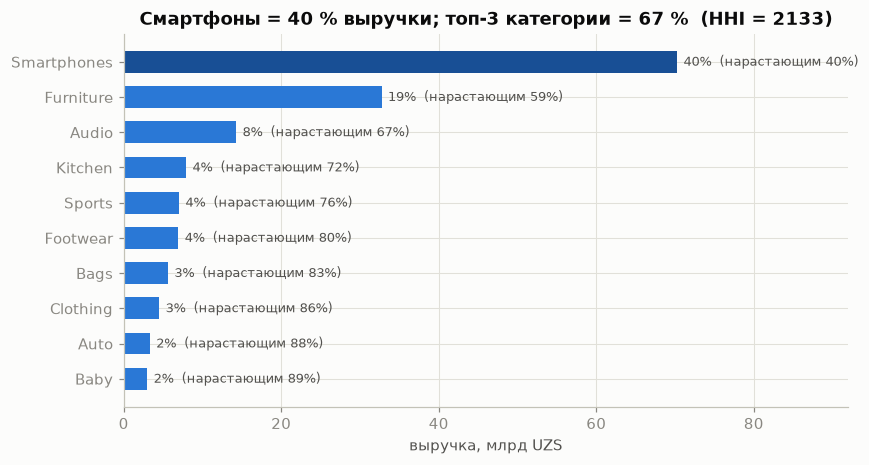

In [19]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
top = cat.head(10).iloc[::-1]
colors = [BLUE if s < 20 else "#184f95" for s in top["share_pct"]]
ax.barh(top["category_name"], top["revenue_bln"], color=colors, height=0.62)
for yv, (rev, share, cum) in enumerate(zip(top["revenue_bln"], top["share_pct"], top["cum_share_pct"])):
    ax.text(rev + 0.8, yv, f"{share:.0f}%  (нарастающим {cum:.0f}%)", va="center", fontsize=8.5, color=INK2)
ax.set_title(f"Смартфоны = {cat.share_pct[0]:.0f} % выручки; топ-3 категории = {cat.cum_share_pct[2]:.0f} %  (HHI = {hhi_cat})")
ax.set_xlabel("выручка, млрд UZS"); ax.set_xlim(0, 92)
save(fig, "h4_categories"); plt.show()

In [20]:
# Отказы оплат по методам + хи-квадрат
pay = q("""
SELECT method, count(*) AS attempts,
       count(*) FILTER (WHERE status='failed') AS failed,
       round(100.0*count(*) FILTER (WHERE status='failed')/count(*), 1) AS fail_pct
FROM ds_payments GROUP BY 1 ORDER BY attempts DESC
""")
obs = np.array([pay["failed"], pay["attempts"] - pay["failed"]]).T
chi2, p_chi, dof, _ = stats.chi2_contingency(obs)
print(pay.to_string(index=False))
print(f"\nχ² = {chi2:.0f}, df = {dof}, p-value = {p_chi:.2e} → методы значимо различаются")

# потерянная выручка: заказы, где ни одна попытка не прошла
lost = q("""
SELECT count(*) AS lost_orders, sum(total_amount)/1e9 AS lost_gmv_bln
FROM ds_orders WHERE status = 'payment_failed'
""")
print(f"\nПотеряно заказов: {lost.lost_orders[0]} на {lost.lost_gmv_bln[0]:.2f} млрд UZS GMV")

     method  attempts  failed  fail_pct
     UZCARD     41752    2028       4.9
       HUMO     29699    1484       5.0
Installment     19771    2027      10.3
       VISA     14610     751       5.1

χ² = 809, df = 3, p-value = 4.25e-175 → методы значимо различаются



Потеряно заказов: 458 на 0.85 млрд UZS GMV


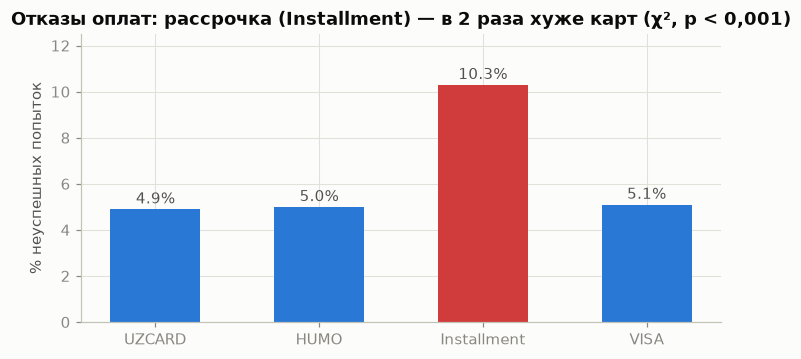

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
colors = [CRITICAL if m == "Installment" else BLUE for m in pay["method"]]
ax.bar(pay["method"], pay["fail_pct"], width=0.55, color=colors)
for i, r in pay.iterrows():
    ax.text(i, r["fail_pct"] + 0.25, f"{r.fail_pct}%", ha="center", fontsize=10, color=INK2)
ax.set_title("Отказы оплат: рассрочка (Installment) — в 2 раза хуже карт (χ², p < 0,001)")
ax.set_ylabel("% неуспешных попыток"); ax.set_ylim(0, 12.5)
save(fig, "h4_fail_rates"); plt.show()

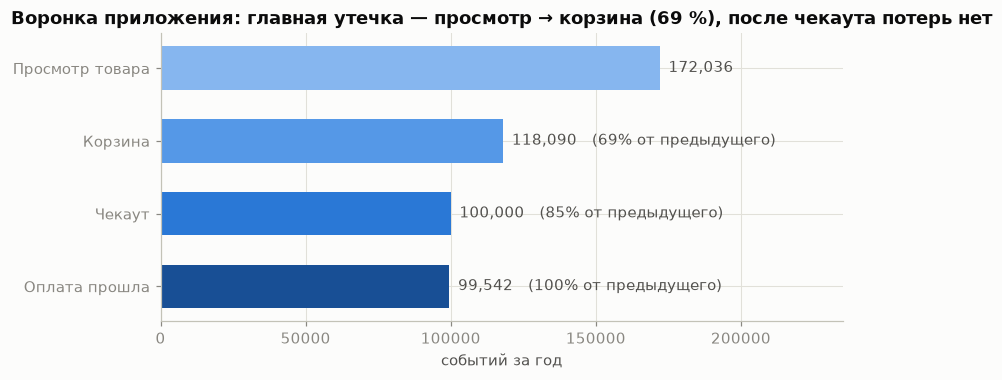

In [22]:
# Воронка приложения (ds_events)
fun = q("""
SELECT event_type, count(*) AS n
FROM ds_events
WHERE event_type IN ('view_product','add_to_cart','checkout_start','payment_success')
GROUP BY 1
""").set_index("event_type").loc[["view_product","add_to_cart","checkout_start","payment_success"]]
steps = ["Просмотр товара","Корзина","Чекаут","Оплата прошла"]
vals = fun["n"].values
ramp = ["#86b6ef", "#5598e7", "#2a78d6", "#184f95"]
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(range(len(vals))[::-1], vals, color=ramp, height=0.6)
for i, v in enumerate(vals):
    conv = "" if i == 0 else f"   ({100*v/vals[i-1]:.0f}% от предыдущего)"
    ax.text(v + 3000, len(vals)-1-i, f"{v:,}{conv}", va="center", fontsize=9.5, color=INK2)
ax.set_yticks(range(len(vals))[::-1], steps); ax.set_xlim(0, 235000)
ax.set_title("Воронка приложения: главная утечка — просмотр → корзина (69 %), после чекаута потерь нет")
ax.set_xlabel("событий за год")
save(fig, "h4_funnel"); plt.show()

**Вывод H4.** Выручка концентрирована: **Smartphones — 40 %**, топ-3 категории — 67 %
(HHI = 2 133 — высокая концентрация), **топ-10 % продавцов дают 49,5 % оборота** — сбои у
малого числа партнёров/категорий бьют по всей выручке. В платежах аномалия одна:
**Installment отказывает в 10,3 %** случаев против ~5 % у карт (χ², p < 0,001); всего
недоведённых заказов 458 на **0,8 млрд UZS** GMV. Воронка приложения здорова после
чекаута (>99,5 %), главная утечка — этап «просмотр → корзина» (69 %).

---

## Итог: что случилось и что делать

### Диагноз (RU)

1. **Бизнес растёт** +6,0 %/мес; «просадка заказов» в декабре — коррекция после пика
   ноября (−12 % MoM, но +8 % к октябрю и лишь −5 % от тренда). Спада бизнеса нет.
2. **Реальная проблема августа** — месячный логистический коллапс в Самарканде:
   93,5 % доставок просрочено (в норме 8,2 %), p < 0,001. Все типы курьеров — причина
   системная (хаб/диспетчеризация/подрядчик города).
3. **Последствия:** +73 % тикетов (весь прирост — late_delivery, 62 % из Самарканда),
   рейтинг города 4,2 → 2,76. Отток не случился (p = 0,50) — повезло, окно ещё открыто.
4. **Фоновые риски:** концентрация выручки (40 % — смартфоны, 49,5 % — топ-10 % продавцов)
   и рассрочка с двойным уровнем отказов (10,3 %).

### План действий для заказчика

| # | Мера | Ожидаемый эффект |
|---|---|---|
| 1 | Разбор инцидента с логистическим подрядчиком Самарканда; SLA со штрафами | защита от повторения |
| 2 | Алерт: если % late по городу превышает базовый уровень на 5 п.п. 3 дня подряд — эскалация | обнаружение за 3 дня, а не через месяц |
| 3 | Кампания извинений/промокодов для 940 пользователей, задетых в августе | закрепить не случившийся отток |
| 4 | Аудит платёжного шлюза рассрочки (10,3 % отказов) | до +0,4 млрд UZS GMV/год |
| 5 | Диверсификация: развитие категорий за пределами топ-3, снижение HHI | устойчивость выручки |

### Xulosa (UZ)

1. **Biznes barqaror o'smoqda** (+5,8 %/oy); dekabrdagi «pasayish» — noyabr cho'qqisidan
   keyingi mavsumiy korreksiya, trendga nisbatan og'ish yo'q.
2. **Asl muammo** — 2025-yil avgustda Samarqanddagi logistika inqirozi: yetkazmalarning
   **93,5 %** kechikkan (norma 8,7 %), barcha kuryer turlari — sabab tizimli.
3. **Oqibatlar:** shikoyatlar +73 %, shahar reytingi 4,2 → 2,76. Mijozlar oqib ketmagan
   (p = 0,50) — imkoniyat hali qo'ldan ketmagan.
4. **Tavsiyalar:** Samarqand pudratchisi bilan SLA va jarimalar; shahar kesimida kechikish
   alertlari (3 kun qoidasi); zarar ko'rgan 940 mijozga promo-aksiya; Installment to'lov
   shlyuzini audit qilish (10,3 % rad); daromad diversifikatsiyasi.

---

### Соответствие требованиям проекта

| Требование | Где выполнено |
|---|---|
| JOIN | H2–H4: `ds_orders⋈ds_deliveries⋈ds_couriers`, `ds_order_items⋈ds_products⋈ds_categories`, `ds_reviews⋈ds_orders` … |
| GROUP BY | во всех гипотезах |
| Подзапрос / CTE | H1 `WITH monthly`, H2 `WITH d`, H3 `WITH first_aug`, H4 `WITH cat_rev/m_rev` + коррелированный подзапрос `EXISTS` |
| Оконные функции | `LAG` (H1), `AVG OVER ROWS 6 PRECEDING` (H2), `SUM OVER`, `RANK`, `NTILE` (H4) |
| ≥2 графика на гипотезу | H1 — 2, H2 — 3, H3 — 3, H4 — 3 |
| Стат. проверка (для трека D — у каждого) | H1: тренд-регрессия + 95 % ДИ; H2: z-тест долей + ДИ; H3: Манна–Уитни + z-тест; H4: χ² + HHI/Парето |
| Без ML | только SQL, pandas, описательная и проверочная статистика |